In [41]:
from skimage.io import imread
import numpy as np
import cupy as cp
from tnia.deconvolution.pad import pad, pad_to_largest, unpad, get_next_smooth

In [77]:
astig_name = r'/home/bnorthan/images/tnia-python-images/imagesc/2026_03_30_2d_deconvolution_czi/astigmatic.tif'
astig_name = r'/home/bnorthan/images/tnia-python-images/imagesc/2026_03_30_2d_deconvolution_czi/astigmatic_psf_beads.tif'
astig = imread(astig_name)
print(astig.shape)

(199, 45, 45)


(199, 45, 45) float32


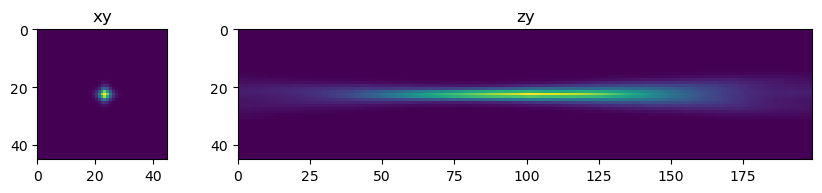

In [78]:
from tnia.plotting.projections import show_xy_zy_slice_center
fig = show_xy_zy_slice_center(astig)
print(astig.shape, astig.dtype)

In [79]:
## find center of mass of the image
from scipy.ndimage import center_of_mass
com = center_of_mass(astig)
com = [int(c) for c in com]
print(com)

[96, 22, 22]


(183, 45, 45)


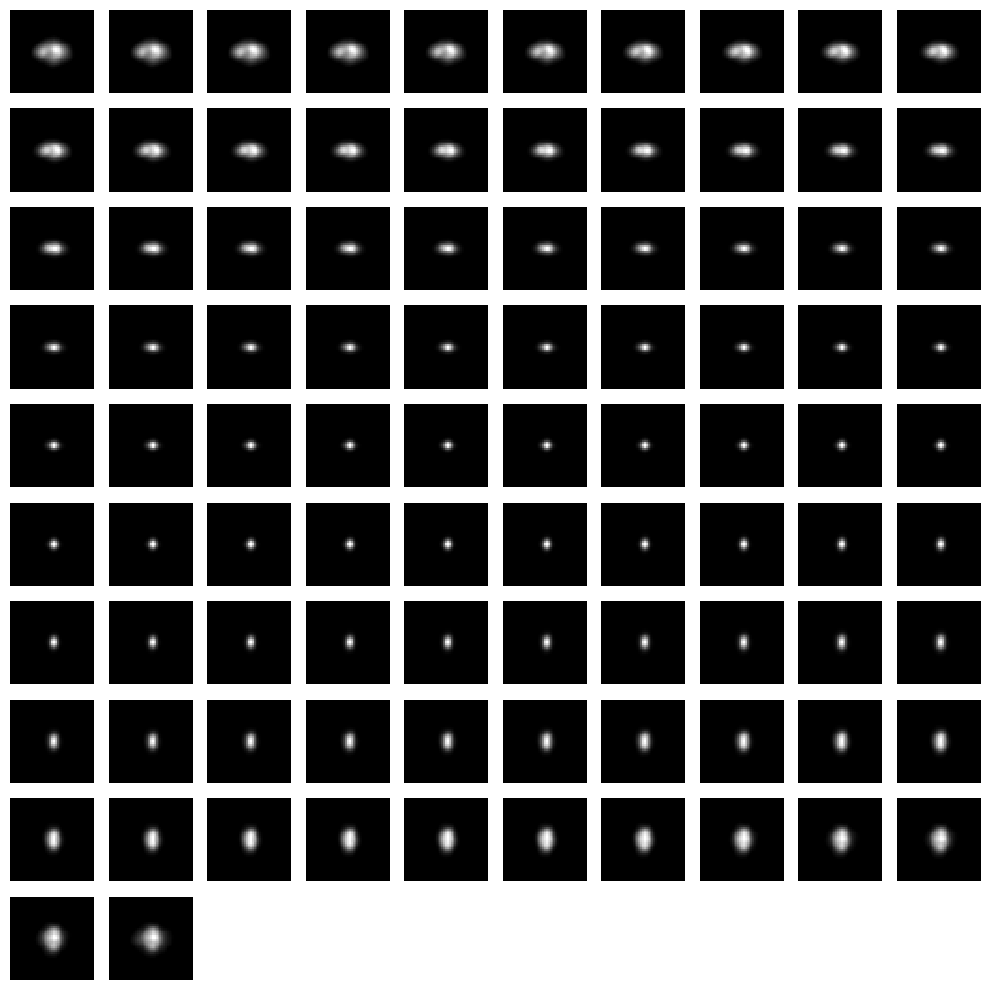

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# crop xy center +-22 (size 45)
crop_half_size_xy = 22
crop_half_size_z = 91
cz, cy, cx = com
cropped = astig[:, cy-crop_half_size_xy:cy+crop_half_size_xy+1, cx-crop_half_size_xy:cx+crop_half_size_xy+1].astype(np.float32)
cropped = cropped[cz-crop_half_size_z:cz+crop_half_size_z+1, :, :]
print(cropped.shape)
psf = cropped/cropped.sum()
# crop z center +-50 (size 199)
#psf = psf[cz-50:cz+51, :, :]

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
idx = 0
for i in range(10):
    for j in range(10):
        if idx < psf.shape[0]:
            axes[i, j].imshow(psf[idx], cmap='gray')
        idx = idx+2
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [81]:
print(f'cropped shape: {cropped.shape}, cropped sum: {cropped.sum()}, cropped dtype: {cropped.dtype}')
print(f'psf shape: {psf.shape}, psf sum: {psf.sum()}, psf dtype: {psf.dtype}')

cropped shape: (183, 45, 45), cropped sum: 0.9433231949806213, cropped dtype: float32
psf shape: (183, 45, 45), psf sum: 0.9999998211860657, psf dtype: float32


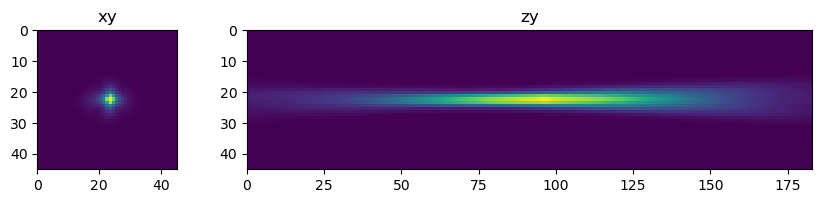

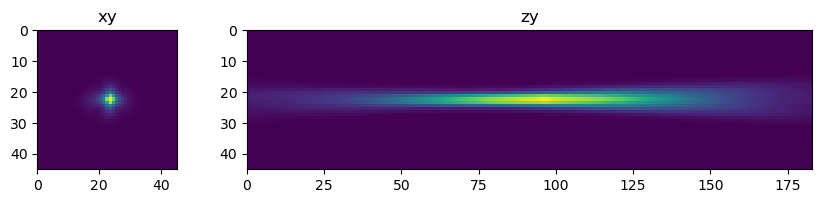

In [82]:
from tnia.plotting.projections import show_xy_zy_max
fig = show_xy_zy_max(psf)
fig = show_xy_zy_max(cropped)

emitter location: (75, 22, 22)


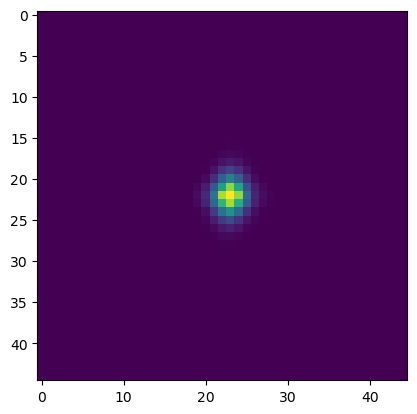

In [83]:
emitter_location = 75, cropped.shape[1]//2, cropped.shape[2]//2
print(f'emitter location: {emitter_location}')
emitter_offset = cropped.shape[0]//2 - emitter_location[0]
psf_plane = cropped.shape[0]//2 + emitter_offset
image=cropped[psf_plane, :, :]
truth = np.zeros_like(cropped)
truth[emitter_location] = cropped.sum()

#estimate = truth.copy()
first_guess = np.ones_like(cropped)*cropped.mean()
# add trivial dimension
image = np.expand_dims(image, axis=0)
plt.imshow(image.squeeze())

In [84]:
type(truth)

numpy.ndarray

In [85]:
extended_size = [image.shape[i]+2*int(psf.shape[i]) for i in range(len(image.shape))]
#extended_size = get_next_smooth(extended_size)
print(f'extended size: {extended_size}')

HTones = np.ones_like(image)

# pad the image, psf and HTOnes array to the extended size computed above
original_size = image.shape
image,_=pad(image, extended_size, 'constant')
HTones,_=pad(HTones, extended_size, 'constant')
psf,_=pad(psf, extended_size, 'constant')
first_guess,_=pad(first_guess, extended_size, 'constant')
truth, _ = pad(truth, extended_size, 'constant')
print(image.shape, psf.shape, HTones.shape)


extended size: [367, 135, 135]
(367, 135, 135) (367, 135, 135) (367, 135, 135)


In [86]:
image = image.astype(np.float32)
image = cp.array(image)
psf = psf.astype(np.float32)
psf = cp.array(psf)
HTones = cp.array(HTones, cp.float32)
first_guess = cp.array(first_guess, cp.float32)
otf = cp.fft.fftn(cp.fft.ifftshift(psf))
otf_ = cp.conjugate(otf)
delta = 1e-6
HTones = cp.real(cp.fft.ifftn(cp.fft.fftn(HTones) * otf_))
HTones[HTones<0] = 0

In [87]:
print(HTones.min(), HTones.max(), HTones.mean())

0.0 0.0066424934 0.0003027548


In [88]:
num_iterations = 400
delta = 1e-8
#estimate = cp.ones_like(image)*cp.mean(image)
estimate = first_guess.copy()
#estimate = HTones.copy()
#estimate = cp.array(truth.copy())
#estimate = cp.real(cp.fft.ifftn(cp.fft.fftn(estimate) * otf))
estimate[estimate<0] = 0
for i in range(num_iterations):
    reblurred = cp.real(cp.fft.ifftn(cp.fft.fftn(estimate) * otf))
    ratio = image / (reblurred+delta)
    correction=cp.real((cp.fft.ifftn(cp.fft.fftn(ratio) * otf_)))
    #correction[correction<0] = delta
    correction_normalized = correction/HTones
    correction_normalized[HTones<delta] = 1
    estimate = estimate * correction_normalized

In [89]:
estimate.min(), estimate.max(), estimate.mean()

(array(0., dtype=float32),
 array(0.07226983, dtype=float32),
 array(1.3953839e-07, dtype=float32))

67 67 75


Text(0.5, 0.98, 'correction normalized')

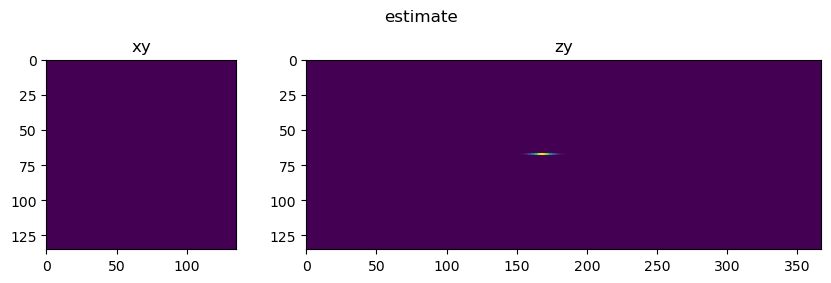

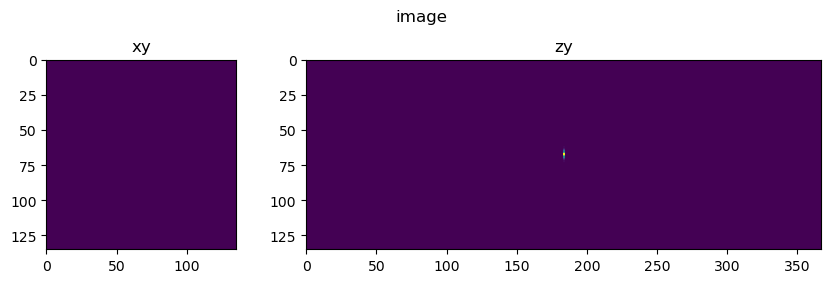

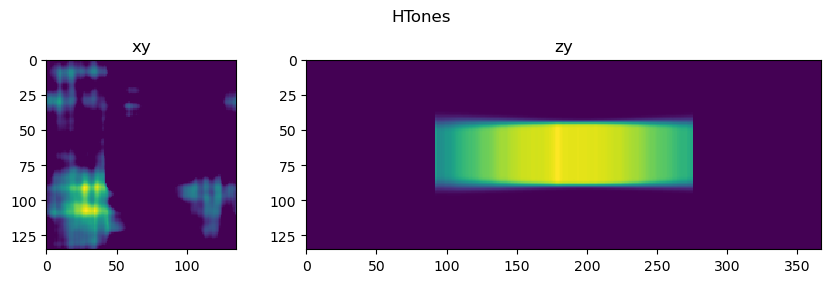

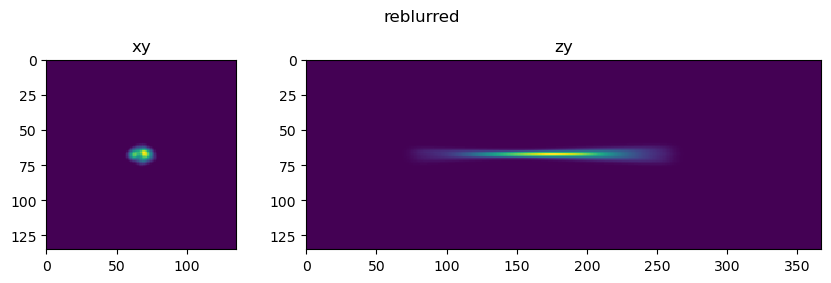

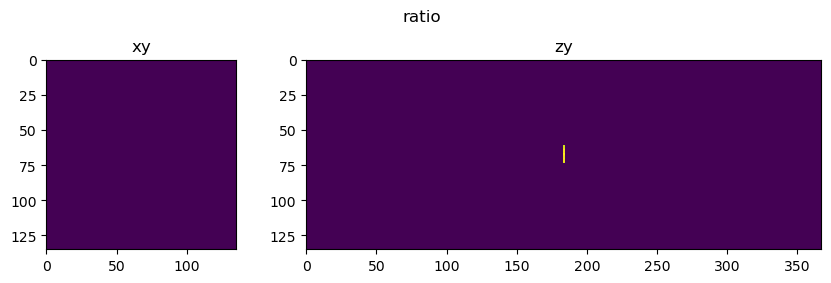

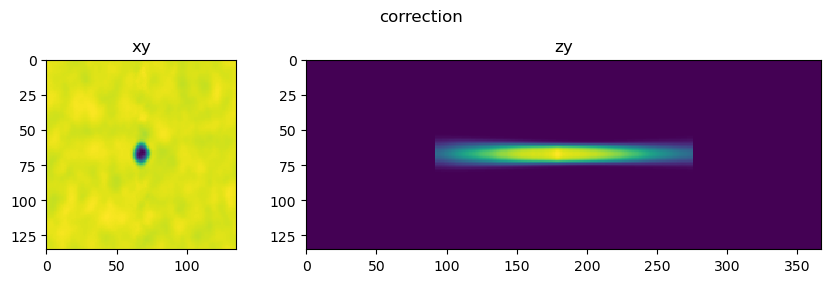

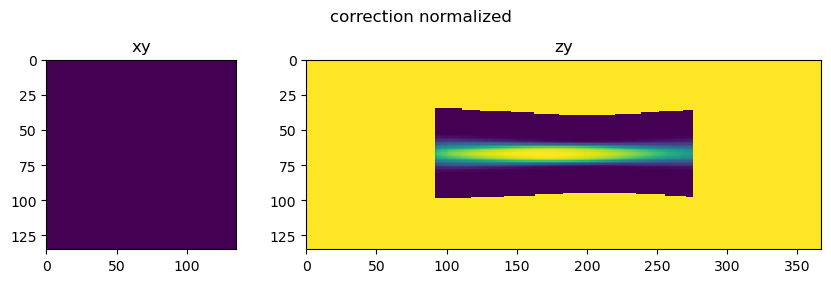

In [90]:
from tnia.plotting.projections import show_xy_zy_slice
x_ = estimate.shape[2]//2
y_ = estimate.shape[1]//2
z_ = emitter_location[0]
print(x_, y_, z_)
fig = show_xy_zy_slice(estimate.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('estimate')
fig = show_xy_zy_slice(image.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('image')
fig = show_xy_zy_slice(HTones.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('HTones')
fig = show_xy_zy_slice(reblurred.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('reblurred')
fig = show_xy_zy_slice(ratio.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('ratio')
fig = show_xy_zy_slice(correction.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('correction')
fig = show_xy_zy_slice(correction_normalized.get(), x_, y_, z_, show_cross_hairs=False)
fig.suptitle('correction normalized')


In [76]:
import napari 
viewer = napari.Viewer()
viewer.add_image(truth, name='truth')
viewer.add_image(estimate.get(), name='estimate')
viewer.add_image(image.get(), name='image')
viewer.add_image(reblurred.get(), name='reblurred')
viewer.add_image(ratio.get(), name='ratio')
viewer.add_image(correction.get(), name='correction')
viewer.add_image(HTones.get(), name='HTones')
viewer.add_image(correction_normalized.get(), name='correction_normalized')

<Image layer 'correction_normalized' at 0x717425418e20>

In [18]:
correction.min(), correction.max()

(array(nan, dtype=float32), array(nan, dtype=float32))

In [21]:
HTones.min(), HTones.max()

(array(-4.784257e-10, dtype=float32), array(0.00586717, dtype=float32))

67 67 75
0.9998657 1.0001423


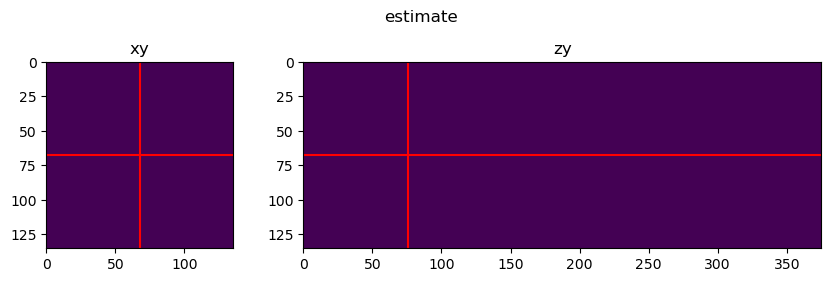

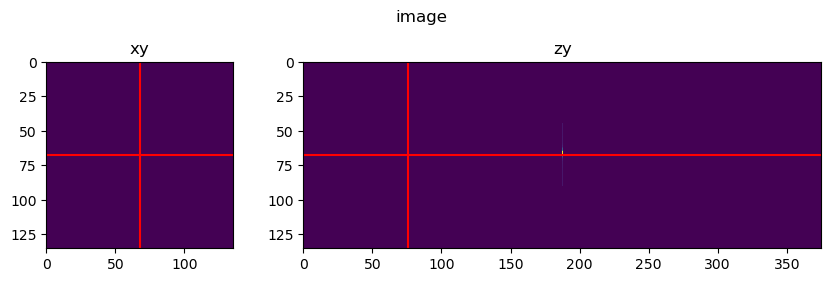

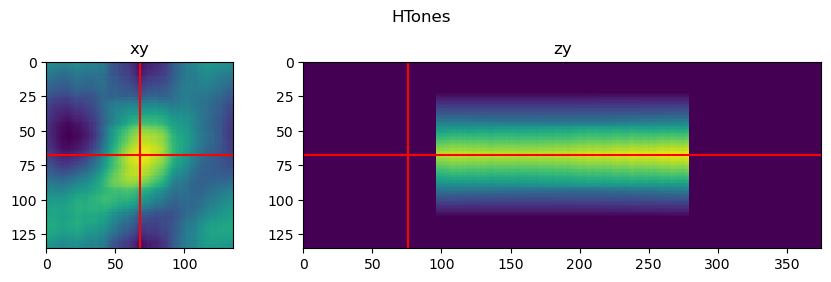

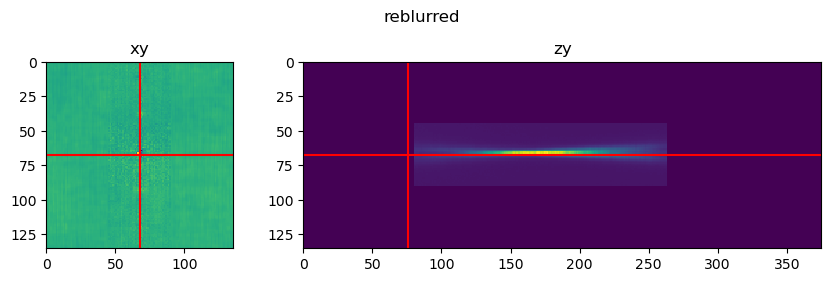

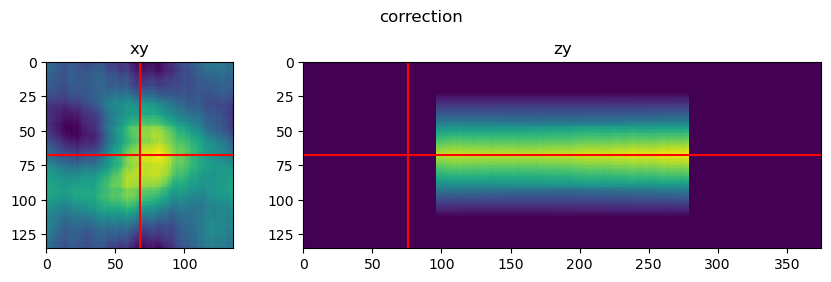

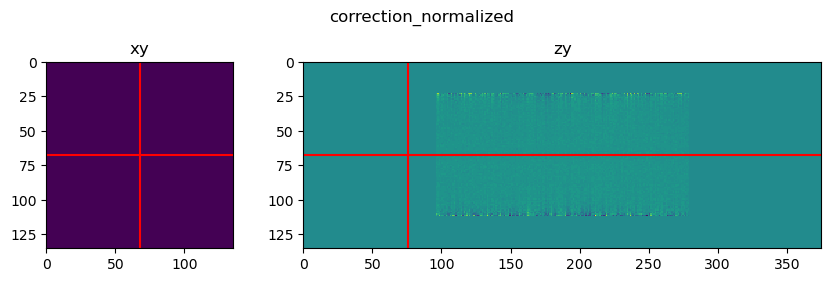

In [23]:
from tnia.plotting.projections import show_xy_zy_slice
x_ = correction.shape[2]//2
y_ = correction.shape[1]//2
z_ = emitter_location[0] 
print(x_, y_, z_)
fig = show_xy_zy_slice(estimate.get(), x_, y_, z_)
fig.suptitle('estimate')
fig = show_xy_zy_slice(image.get(), x_, y_, z_)
fig.suptitle('image')
fig = show_xy_zy_slice(HTones.get(), x_, y_, z_)
fig.suptitle('HTones')
fig = show_xy_zy_slice(reblurred.get(), x_, y_, z_)
fig.suptitle('reblurred')
fig = show_xy_zy_slice(correction.get(), x_, y_, z_)
fig.suptitle('correction')
fig = show_xy_zy_slice(correction_normalized.get(), x_, y_, z_)
fig.suptitle('correction_normalized')
print(correction_normalized.min(), correction_normalized.max())

In [26]:
import napari
viewer = napari.Viewer()
viewer.add_image(HTones.get(), name='HTones')

<Image layer 'HTones' at 0x7fa934ecb220>